In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
col_names = [
    'engine_id', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]

def load_cmapss(subset, split='train'):
    path = f'../data/raw/{split}_FD00{subset}.txt'
    df = pd.read_csv(path, sep='\s+', header=None, names=col_names)
    df['subset'] = f'FD00{subset}'
    return df

def add_rul(df):
    max_cycle = df.groupby(['engine_id', 'subset'])['cycle'].max().reset_index()
    max_cycle.columns = ['engine_id', 'subset', 'max_cycle']
    df = df.merge(max_cycle, on=['engine_id', 'subset'])
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop(columns=['max_cycle'], inplace=True)
    return df

train_dfs = [load_cmapss(i) for i in range(1, 5)]
train_df = pd.concat(train_dfs, ignore_index=True)
train_df = add_rul(train_df)

print(f"Data loaded: {train_df.shape} ✅")

Data loaded: (160359, 28) ✅


In [3]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]

# Sensors with near-zero variance carry no information
std_devs = train_df[sensor_cols].std()
useless_sensors = std_devs[std_devs < 0.01].index.tolist()
useful_sensors = std_devs[std_devs >= 0.01].index.tolist()

print(f"Dropped (near-zero variance): {useless_sensors}")
print(f"Kept for feature engineering: {useful_sensors}")
print(f"Useful sensor count: {len(useful_sensors)}")

Dropped (near-zero variance): ['sensor_16']
Kept for feature engineering: ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Useful sensor count: 20


In [4]:
# Sort so rolling is computed correctly per engine
train_df = train_df.sort_values(['subset', 'engine_id', 'cycle']).reset_index(drop=True)

WINDOW = 5

for sensor in useful_sensors:
    train_df[f'{sensor}_roll_mean'] = (
        train_df.groupby(['subset', 'engine_id'])[sensor]
        .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
    )
    train_df[f'{sensor}_roll_std'] = (
        train_df.groupby(['subset', 'engine_id'])[sensor]
        .transform(lambda x: x.rolling(WINDOW, min_periods=1).std().fillna(0))
    )

new_cols = len(useful_sensors) * 2
print(f"Rolling features added: {new_cols} new columns ✅")
print(f"Total columns now: {train_df.shape[1]}")

Rolling features added: 40 new columns ✅
Total columns now: 68


In [5]:
# Faster lag features using shift within sorted groups
LAGS = [1, 2, 3]

lag_frames = []
for sensor in useful_sensors:
    for lag in LAGS:
        col = train_df.groupby(['subset', 'engine_id'])[sensor].shift(lag)
        col.name = f'{sensor}_lag{lag}'
        lag_frames.append(col)

# Join all lag columns at once instead of one by one
lag_df = pd.concat(lag_frames, axis=1).fillna(0)
train_df = pd.concat([train_df, lag_df], axis=1)

lag_cols = [c for c in train_df.columns if '_lag' in c]
print(f"Lag features added: {len(lag_cols)} new columns ✅")
print(f"Total columns now: {train_df.shape[1]}")

Lag features added: 60 new columns ✅
Total columns now: 128


In [6]:
# How fast is each sensor changing cycle over cycle?
# Rapid change = potential anomaly

for sensor in useful_sensors:
    train_df[f'{sensor}_delta'] = (
        train_df.groupby(['subset', 'engine_id'])[sensor]
        .transform(lambda x: x.diff().fillna(0))
    )

delta_cols = [c for c in train_df.columns if '_delta' in c]
print(f"Delta (rate of change) features added: {len(delta_cols)} ✅")
print(f"Total columns now: {train_df.shape[1]}")

Delta (rate of change) features added: 20 ✅
Total columns now: 148


In [7]:
# Flag readings that are statistically unusual (z-score > 3)
# This is what SensorMind will use to trigger alerts

for sensor in useful_sensors:
    mean = train_df[sensor].mean()
    std  = train_df[sensor].std()
    train_df[f'{sensor}_anomaly'] = (
        (np.abs(train_df[sensor] - mean) / std) > 3
    ).astype(int)

anomaly_cols = [c for c in train_df.columns if '_anomaly' in c]

# Summary of anomalies found
total_anomalies = train_df[anomaly_cols].sum().sum()
print(f"Anomaly flag columns added: {len(anomaly_cols)} ✅")
print(f"Total anomalous readings flagged: {total_anomalies:,}")
print()
print(train_df[anomaly_cols].sum().sort_values(ascending=False).head(10))

Anomaly flag columns added: 20 ✅
Total anomalous readings flagged: 1

sensor_14_anomaly    1
sensor_1_anomaly     0
sensor_3_anomaly     0
sensor_2_anomaly     0
sensor_4_anomaly     0
sensor_5_anomaly     0
sensor_7_anomaly     0
sensor_6_anomaly     0
sensor_9_anomaly     0
sensor_10_anomaly    0
dtype: int64


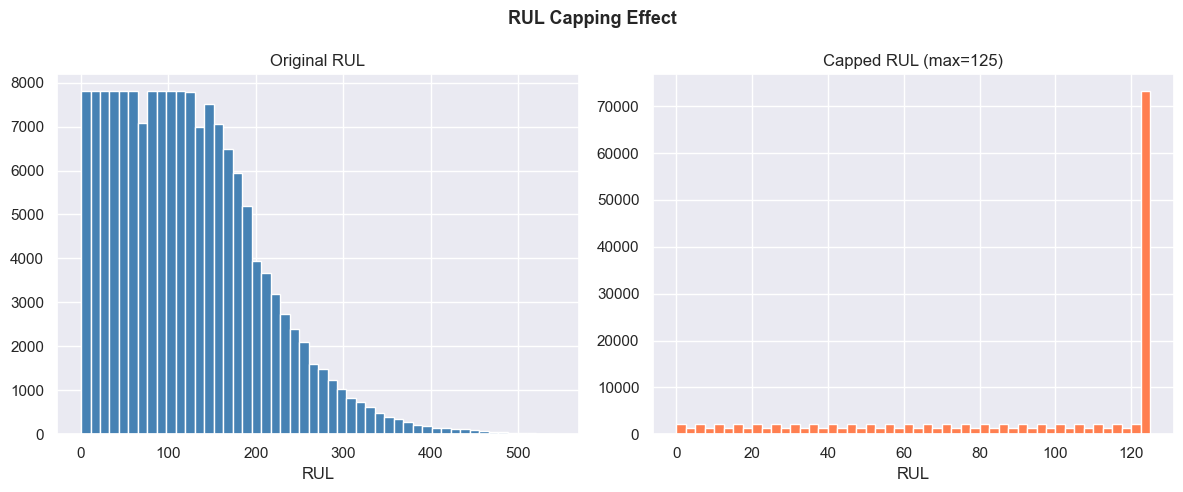

Plot 12 saved ✅


In [8]:
# Engines early in life all look "healthy"
# Capping RUL at 125 helps the model focus on degradation zone
# This is standard practice for CMAPSS

RUL_CAP = 125
train_df['RUL_capped'] = train_df['RUL'].clip(upper=RUL_CAP)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train_df['RUL'], bins=50, color='steelblue', edgecolor='white')
plt.title('Original RUL')
plt.xlabel('RUL')

plt.subplot(1, 2, 2)
plt.hist(train_df['RUL_capped'], bins=50, color='coral', edgecolor='white')
plt.title(f'Capped RUL (max={RUL_CAP})')
plt.xlabel('RUL')

plt.suptitle('RUL Capping Effect', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot12_rul_capping.png', dpi=150)
plt.show()
print("Plot 12 saved ✅")

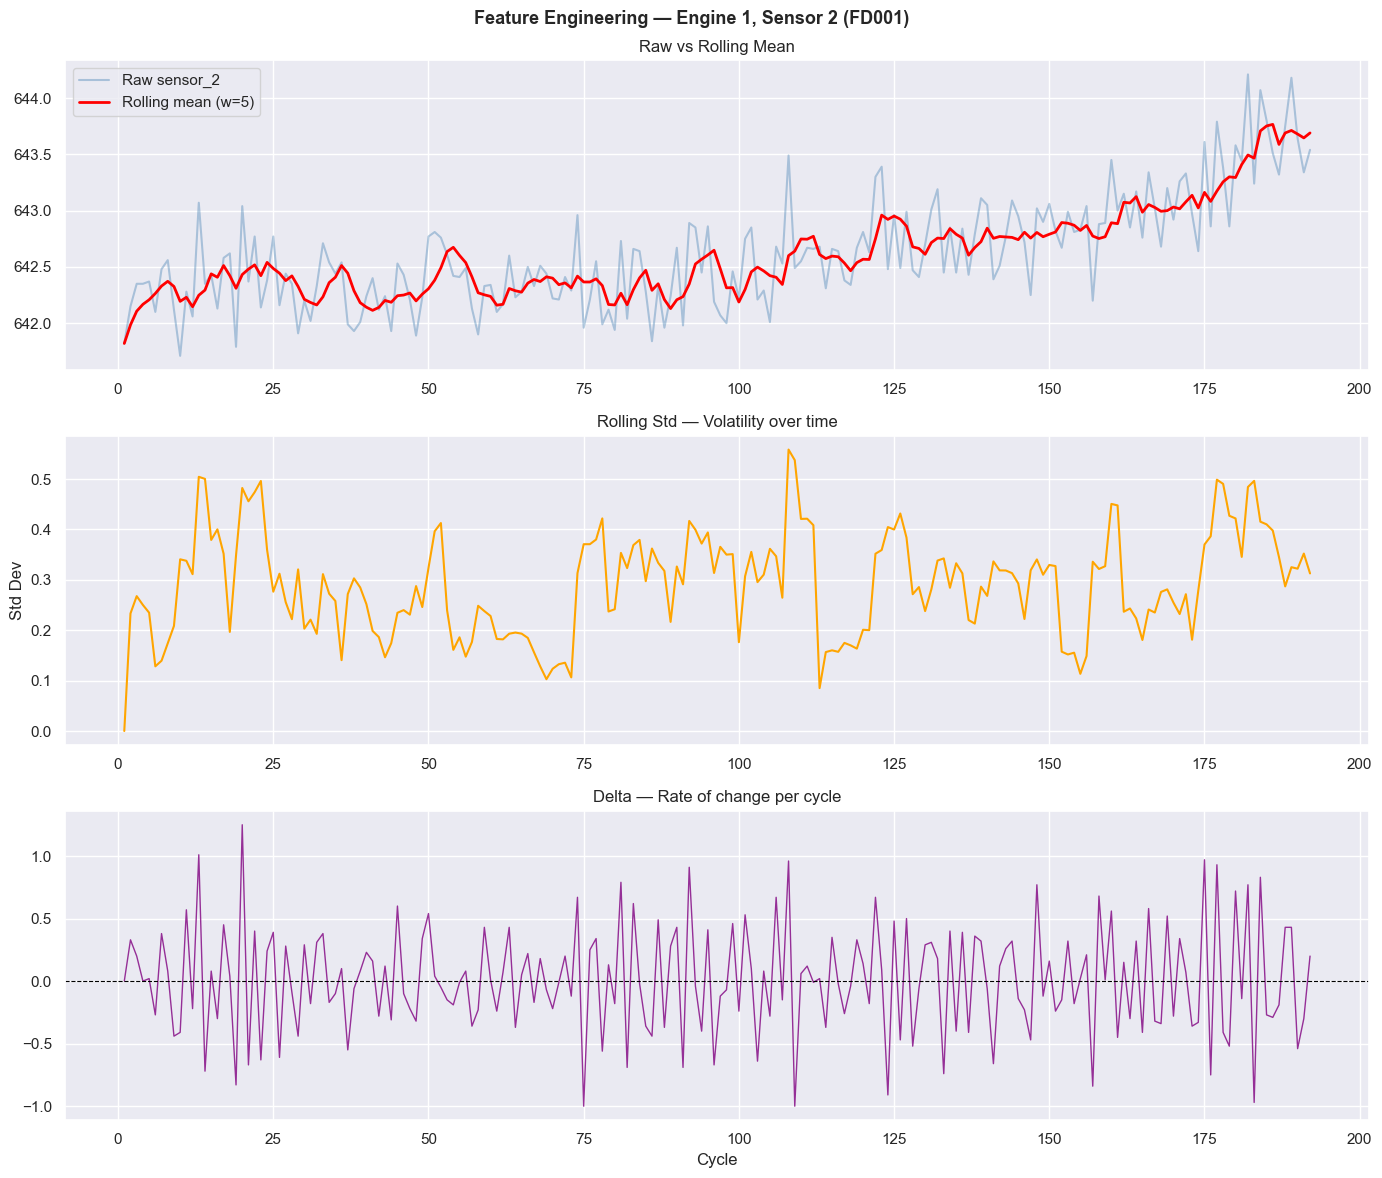

Plot 13 saved ✅


In [9]:
engine_sample = train_df[
    (train_df['engine_id'] == 1) & 
    (train_df['subset'] == 'FD001')
]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Raw vs rolling mean
axes[0].plot(engine_sample['cycle'], engine_sample['sensor_2'], 
             alpha=0.4, color='steelblue', label='Raw sensor_2')
axes[0].plot(engine_sample['cycle'], engine_sample['sensor_2_roll_mean'], 
             color='red', linewidth=2, label='Rolling mean (w=5)')
axes[0].set_title('Raw vs Rolling Mean')
axes[0].legend()

# Rolling std (volatility)
axes[1].plot(engine_sample['cycle'], engine_sample['sensor_2_roll_std'], 
             color='orange', linewidth=1.5)
axes[1].set_title('Rolling Std — Volatility over time')
axes[1].set_ylabel('Std Dev')

# Delta (rate of change)
axes[2].plot(engine_sample['cycle'], engine_sample['sensor_2_delta'], 
             color='purple', linewidth=1, alpha=0.8)
axes[2].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Delta — Rate of change per cycle')
axes[2].set_xlabel('Cycle')

plt.suptitle('Feature Engineering — Engine 1, Sensor 2 (FD001)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot13_engineered_features.png', dpi=150)
plt.show()
print("Plot 13 saved ✅")

In [10]:
# Select final feature set for ML models
feature_cols = (
    ['engine_id', 'cycle', 'subset'] +
    ['op_setting_1', 'op_setting_2', 'op_setting_3'] +
    useful_sensors +
    [f'{s}_roll_mean' for s in useful_sensors] +
    [f'{s}_roll_std'  for s in useful_sensors] +
    [f'{s}_lag1'      for s in useful_sensors] +
    [f'{s}_lag2'      for s in useful_sensors] +
    [f'{s}_lag3'      for s in useful_sensors] +
    [f'{s}_delta'     for s in useful_sensors] +
    [f'{s}_anomaly'   for s in useful_sensors] +
    ['RUL', 'RUL_capped']
)

final_df = train_df[feature_cols]

# Save to features folder
final_df.to_parquet('../data/features/train_features.parquet', index=False)

print(f"Final feature set saved ✅")
print(f"Shape         : {final_df.shape}")
print(f"Feature count : {final_df.shape[1] - 3} (excluding id/target cols)")
print(f"\nSaved to: data/features/train_features.parquet")

Final feature set saved ✅
Shape         : (160359, 168)
Feature count : 165 (excluding id/target cols)

Saved to: data/features/train_features.parquet
